In [48]:
import sys
from pathlib import Path
ROOT = Path.cwd().parents[0]   # repo root
sys.path.insert(0, str(ROOT))
##
import pandas as pd 
import numpy as np
from datetime import datetime, timedelta

from src.features.feature_engineering import add_time_and_lag_features
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.base import clone
from sklearn.linear_model import Ridge

from src.data.build_clean_df import load_stations_data
from src.simulation.station_states_sim import simulate_bike_day, simulate_day_with_rebalancing

import matplotlib.pyplot as plt
import matplotlib.dates as mdates

### Getting predictions

In [76]:
# if this cell is not working please run the models.ipynb notebook to generate the processed data csv
demand = pd.read_csv("../data/processed/divvy_hourly_demand_weather.csv")
demand["hour"] = pd.to_datetime(demand["hour"])
demand = add_time_and_lag_features(demand=demand,lags=(1, 24, 168),drop_na_lags=True)
demand.head()

stations = load_stations_data()

In [77]:
y_dep = demand["departures"]
y_arr = demand["arrivals"]

feature_cols = [
    "hour_sin","hour_cos",
    "dow_sin","dow_cos",
    "month_sin","month_cos",
    "is_weekend",
    "temp","tmin","tmax","rhum","prcp","snwd","wspd","pres",
    "dep_lag_1","dep_lag_24", 'dep_lag_168',
    "arr_lag_1","arr_lag_24", "arr_lag_168"
]

X = demand[feature_cols]

split_time = demand["hour"].quantile(0.8)

train = demand["hour"] <= split_time
test  = demand["hour"] > split_time

X_train = X[train]
X_test  = X[test]

y_dep_train = y_dep[train]
y_dep_test  = y_dep[test]

y_arr_train = y_arr[train]
y_arr_test  = y_arr[test]

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


model = Ridge(alpha=1.0, random_state=42)

print(f"Training Ridge...")

# departures
mdl_dep = clone(model)
mdl_dep.fit(X_train, y_dep_train)
pred_dep = mdl_dep.predict(X_test)

# arrivals
mdl_arr = clone(model)
mdl_arr.fit(X_train, y_arr_train)
pred_arr = mdl_arr.predict(X_test)

pred_dep = np.clip(pred_dep, 0, None)
pred_arr = np.clip(pred_arr, 0, None)

pred_net = pred_dep - pred_arr
true_net = y_dep_test - y_arr_test

results = pd.DataFrame([{
    "model": "Ridge",
    "dep_MAE": mean_absolute_error(y_dep_test, pred_dep),
    "dep_RMSE": rmse(y_dep_test, pred_dep),
    "arr_MAE": mean_absolute_error(y_arr_test, pred_arr),
    "arr_RMSE": rmse(y_arr_test, pred_arr),
    "net_MAE": mean_absolute_error(true_net, pred_net),
    "net_RMSE": rmse(true_net, pred_net),
}])
results.head()

# build pred_df 
pred_df = demand[test][['station_id','hour','departures','arrivals','net_demand']].rename(columns={
    "net_demand" : "true_net_demand",
    "departures" : "true_departures",
    "arrivals" : "true_arrivals"
})
pred_df['pred_arrivals'] = pred_arr.round()
pred_df['pred_departures'] = pred_dep.round()
pred_df['pred_net_demand'] = pred_net.round()

pred_df = pred_df.merge(stations, left_on='station_id', right_on='id', how='left')
pred_df.drop(columns=['id'], inplace=True)
pred_df = pred_df[['hour','station_id','pred_departures', 'true_departures','pred_arrivals', 'true_arrivals',
       'pred_net_demand','true_net_demand','dpcapacity', 'latitude', 'longitude','name']]

# hourly_net_demand = pred_df.groupby(pred_df['hour'])[['pred_net_demand','true_net_demand']].agg(lambda x: x.abs().sum()).reset_index().sort_values(['pred_net_demand'], ascending=False)
# hourly_net_demand[hourly_net_demand['hour']==hour_to_optimize]



Training Ridge...


### Simulation

In [ ]:
#Approximately 3 hours to run

# start_date = datetime.strptime('2017-12-05', '%Y-%m-%d')
# end_date = datetime.strptime('2017-12-19', '%Y-%m-%d')

# current_date = start_date
# while current_date <= end_date:
#     print(current_date.strftime('%Y-%m-%d'))

#     # generate simulation without rebalancing
#     hourly_states_df = simulate_bike_day(pred_df,day = current_date)

#     # generate simulation with rebalancing
#     results_df, metrics_df, optimization_history = simulate_day_with_rebalancing(
#     pred_df = pred_df,
#     stations = stations,
#     day = current_date,
#     gamma=2.85,
#     nb_trucks=1,
#     acceptable_margin=0.2,
#     stations_per_cluster=25,
#     opt_time_limit=30)

#     current_date += timedelta(days=1)


2017-12-05
Simulation saved to simulation_results\without_rebalancing\hourly_states_0.csv
Starting simulation with rebalancing
------------------------------------

Simulating hour 2017-12-05 00:00:00
Clusters to optimize: 1
Optimizing cluster 0
Solver status: Infeasible
Cluster 0 optimized in 0s
Hour 2017-12-05 00:00:00 completed

Simulating hour 2017-12-05 01:00:00
Clusters to optimize: 1
Optimizing cluster 0
Solver status: Infeasible
Cluster 0 optimized in 0s
Hour 2017-12-05 01:00:00 completed

Simulating hour 2017-12-05 02:00:00
Clusters to optimize: 1
Optimizing cluster 0
Solver status: Infeasible
Cluster 0 optimized in 0s
Hour 2017-12-05 02:00:00 completed

Simulating hour 2017-12-05 03:00:00
Clusters to optimize: 1
Optimizing cluster 0
Solver status: Infeasible
Cluster 0 optimized in 0s
Hour 2017-12-05 03:00:00 completed

Simulating hour 2017-12-05 04:00:00
Clusters to optimize: 1
Optimizing cluster 0
Solver status: Infeasible
Cluster 0 optimized in 0s
Hour 2017-12-05 04:00:00 c

In [79]:
# results_df, metrics_df, optimization_history = simulate_day_with_rebalancing(
#     pred_df = pred_df,
#     stations = stations,
#     day = '2017-11-20',
#     gamma=2.85,
#     nb_trucks=1,
#     acceptable_margin=0.2,
#     stations_per_cluster=25,
#     opt_time_limit=3)

### Computing the cost of the rebalancing system

It makes sense to compute the cost depending on : 
- km travelled

Based on a report of the American Transportation Research Institute (https://truckingresearch.org/about-atri/atri-research/operational-costs-of-trucking), the operational costs of a truck is : 

**1,40$ per km**


### Computing the "cost" of the unmeet demand

Based on Divvy pricing (https://divvybikes.com/pricing) :
- **cost of annual plan : 143.9 $**
- **cost of one ride : 1 + 0.2 $ per km**

Based on Trips data for the year 2017 : 
- **88% of trips are made by suscribers**
- **12% of trips are made by customers**

And the average distance of a trip made by a customer is : 
**2.13 km**

In [29]:
0.015* 1.5 * 143.9 * 0.88 + 0.12 * (1+0.2*2.13)

3.0203400000000005

Then the **average cost of unmeet demand is 3 $**. 

Note that this allows to compute **'optimal' gamma, 4 / 1.4 = 2.85**

### Plotting results of the optimization

In [51]:
start_date = datetime.strptime('2017-11-20', '%Y-%m-%d')
end_date = datetime.strptime('2017-12-19', '%Y-%m-%d')
cost_per_km = 1.4
cost_per_unmeet_demand_unit = 3

daily_metrics = {}

current_date = start_date

while current_date <= end_date:
    # read data without rebalancing
    current_date_wo_reb_df = pd.read_csv(f'..\simulation_results\without_rebalancing\hourly_states_{str(current_date)[:-8]}.csv')
    total_failure_magnitude_wo_rb = current_date_wo_reb_df['failure_magnitude'].sum()
    pct_station_time_w_failure_wo_rb = current_date_wo_reb_df['failure'].mean().round(3) * 100
    pct_station_time_w_failure_wo_rb_cap_weighted = ((current_date_wo_reb_df['failure'] * current_date_wo_reb_df['dpcapacity']).sum() / current_date_wo_reb_df['dpcapacity'].sum()).round(3) * 100

    # read data with rebalancing
    current_date_w_reb_df = pd.read_csv(f'..\simulation_results\with_rebalancing\hourly_states_{str(current_date)[:-8]}.csv')
    total_failure_magnitude_w_rb = current_date_w_reb_df['failure_magnitude'].sum()
    pct_station_time_w_failure_w_rb = current_date_w_reb_df['failure'].mean().round(3) * 100
    pct_station_time_w_failure_w_rb_cap_weighted = ((current_date_w_reb_df['failure'] * current_date_w_reb_df['dpcapacity']).sum() / current_date_w_reb_df['dpcapacity'].sum()).round(3) * 100

    # read rebalancing operational data
    current_date_reb_metrics_df = pd.read_csv(f'..\simulation_results\\rebalancing_metrics\hourly_rebalancing_metrics_{str(current_date)[:-8]}.csv')
    total_km_travelled = current_date_reb_metrics_df['total_distance'].sum().round()

    # computing $ metrics 
    rebalancing_cost = (cost_per_km * total_km_travelled).round()
    unmeet_demand_cost_wo_rebalancing = cost_per_unmeet_demand_unit * total_failure_magnitude_wo_rb
    unmeet_demand_cost_w_rebalancing = cost_per_unmeet_demand_unit * total_failure_magnitude_w_rb
    rebalancing_gain = ((total_failure_magnitude_wo_rb - total_failure_magnitude_w_rb) * cost_per_unmeet_demand_unit - rebalancing_cost).round()



    daily_metrics[current_date] = {
        'fail_magnitude_wo_rebal' : total_failure_magnitude_wo_rb,
        'station_time_failed_wo_rebal' : pct_station_time_w_failure_wo_rb,
        'station_time_failed_capw_wo_rebal' : pct_station_time_w_failure_wo_rb_cap_weighted,
        'fail_magnitude_w_rebal' : total_failure_magnitude_w_rb,
        'station_time_failed_w_rebal' : pct_station_time_w_failure_w_rb,
        'station_time_failed_capw_w_rebal' : pct_station_time_w_failure_w_rb_cap_weighted,
        'total_km_travelled' : total_km_travelled,
        'rebalancing cost($)' : rebalancing_cost,
        'unmeet_demand_cost_wo_rebal ($)' : unmeet_demand_cost_wo_rebalancing,
        'unmeet_demand_cost_w_rebal ($)' : unmeet_demand_cost_w_rebalancing,
        'rebalancing_gain ($)' : rebalancing_gain
    }

    current_date += timedelta(days=1)

daily_metrics_df = pd.DataFrame(daily_metrics).T

daily_metrics_df.to_csv('..\\results\\rebalancing_results\\daily_metrics.csv')

In [52]:
daily_metrics_df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 30 entries, 2017-11-20 to 2017-12-19
Data columns (total 11 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   fail_magnitude_wo_rebal            30 non-null     float64
 1   station_time_failed_wo_rebal       30 non-null     float64
 2   station_time_failed_capw_wo_rebal  30 non-null     float64
 3   fail_magnitude_w_rebal             30 non-null     float64
 4   station_time_failed_w_rebal        30 non-null     float64
 5   station_time_failed_capw_w_rebal   30 non-null     float64
 6   total_km_travelled                 30 non-null     float64
 7   rebalancing cost($)                30 non-null     float64
 8   unmeet_demand_cost_wo_rebal ($)    30 non-null     float64
 9   unmeet_demand_cost_w_rebal ($)     30 non-null     float64
 10  rebalancing_gain ($)               30 non-null     float64
dtypes: float64(11)
memory usage: 2.8 KB


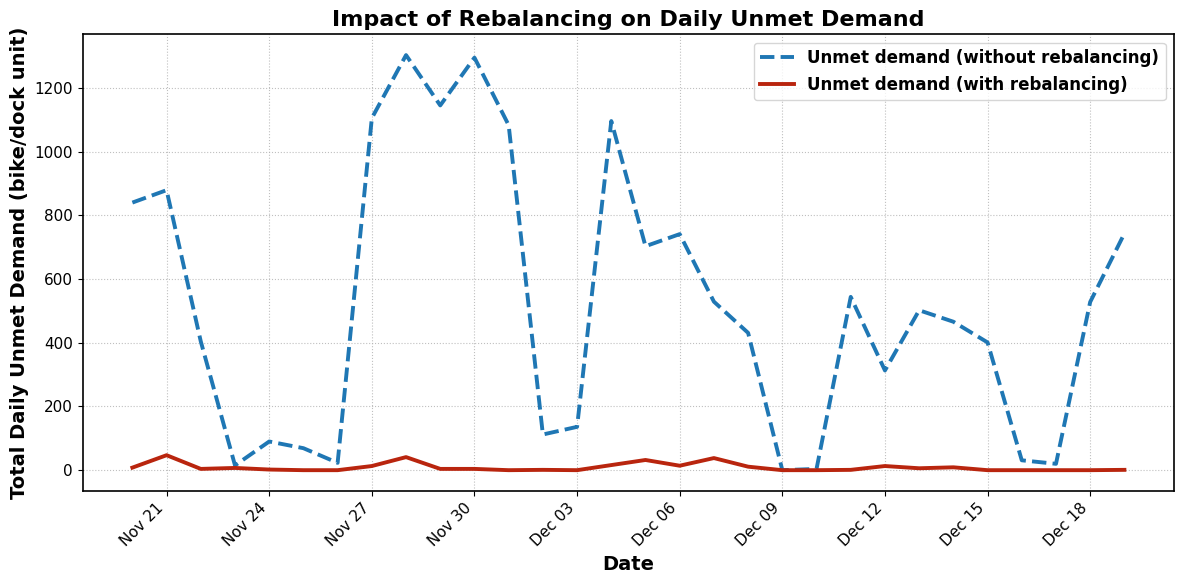

In [53]:
# Ensure datetime index
df = daily_metrics_df.copy()
df.index = pd.to_datetime(df.index)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.8
})

fig, ax = plt.subplots(figsize=(12,6))

color = "#1f77b4"
color2 = "#b9250e"

# Plot lines
ax.plot(
    df.index,
    df['fail_magnitude_wo_rebal'],
    linestyle="--",
    color=color,
    label="Unmet demand (without rebalancing)"
)

ax.plot(
    df.index,
    df['fail_magnitude_w_rebal'],
    linestyle="-",
    color=color2,
    label="Unmet demand (with rebalancing)"
)

# Labels
ax.set_ylabel("Total Daily Unmet Demand (bike/dock unit)", fontweight="bold")
ax.set_xlabel("Date", fontweight="bold")

# Date formatting
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.xticks(rotation=45, ha="right")

# Grid
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

# Thicker axes
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# Title
ax.set_title("Impact of Rebalancing on Daily Unmet Demand", fontweight="bold")

# Legend
legend = ax.legend(loc="upper right", frameon=True)
for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()
plt.show()

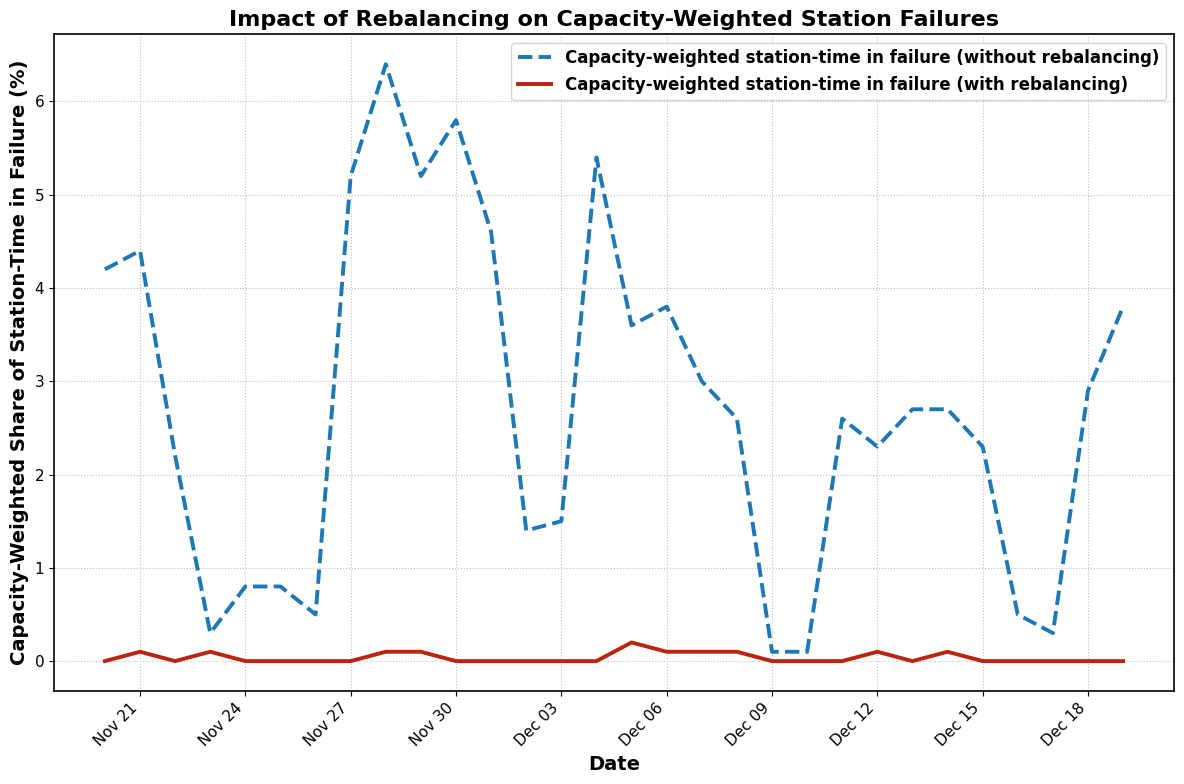

In [55]:
# Ensure datetime index
df = daily_metrics_df.copy()
df.index = pd.to_datetime(df.index)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.8
})

fig, ax = plt.subplots(figsize=(12,8))

color = "#1f77b4"
color2 = "#b9250e"

# Plot lines
ax.plot(
    df.index,
    df['station_time_failed_capw_wo_rebal'],
    linestyle="--",
    color=color,
    label="Capacity-weighted station-time in failure (without rebalancing)"
)

ax.plot(
    df.index,
    df['station_time_failed_capw_w_rebal'],
    linestyle="-",
    color=color2,
    label="Capacity-weighted station-time in failure (with rebalancing)"
)

# Labels
ax.set_ylabel("Capacity-Weighted Share of Station-Time in Failure (%)", fontweight="bold")
ax.set_xlabel("Date", fontweight="bold")

# Date formatting
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))

plt.xticks(rotation=45, ha="right")

# Grid
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

# Thicker axes
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# Title
ax.set_title("Impact of Rebalancing on Capacity-Weighted Station Failures", fontweight="bold")

# Legend
legend = ax.legend(loc="upper right", frameon=True)
for text in legend.get_texts():
    text.set_fontweight("bold")

plt.tight_layout()
plt.show()

C:\Users\pierr\AppData\Local\Temp\ipykernel_14048\560333686.py:49: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  legend = ax.legend(loc="upper left", frameon=True)


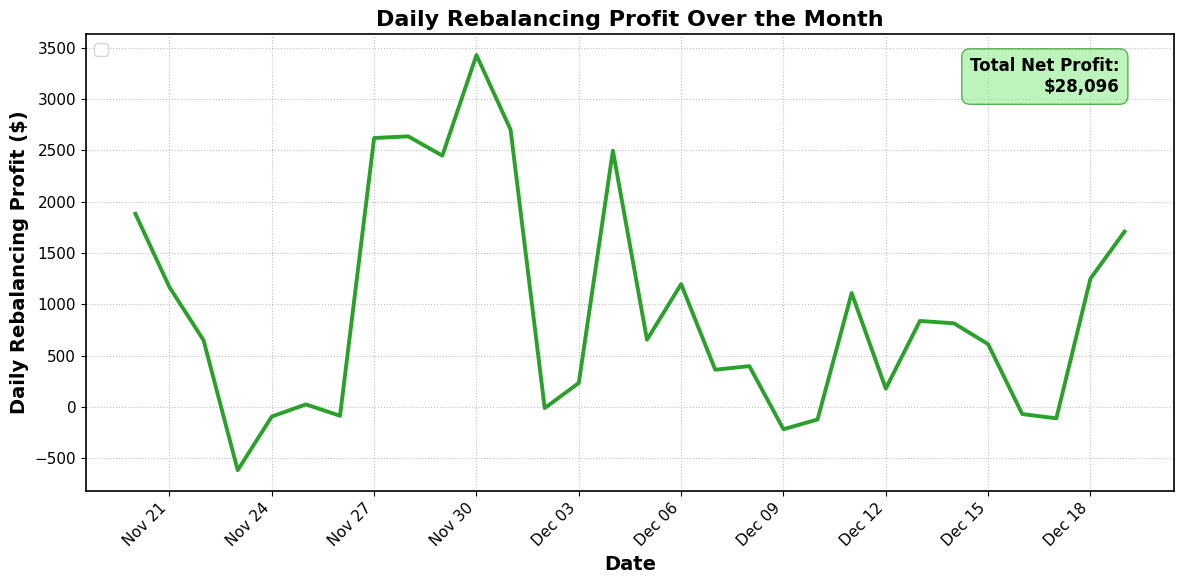

In [62]:
# Ensure datetime index
df = daily_metrics_df.copy()
df.index = pd.to_datetime(df.index)

plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 16,
    "axes.labelsize": 14,
    "axes.titleweight": "bold",
    "axes.labelweight": "bold",
    "legend.fontsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "lines.linewidth": 2.8
})

fig, ax = plt.subplots(figsize=(12,6))

color_gain = "#2ca02c"

# Plot rebalancing gain
ax.plot(
    df.index,
    df['rebalancing_gain ($)'],
    linestyle="-",
    color=color_gain,
)

# Labels
ax.set_ylabel("Daily Rebalancing Profit ($)", fontweight="bold")
ax.set_xlabel("Date", fontweight="bold")

# Date formatting
ax.xaxis.set_major_locator(mdates.DayLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
plt.xticks(rotation=45, ha="right")

# Grid
ax.grid(True, linestyle=":", linewidth=0.8, alpha=0.8)

# Thicker axes
for spine in ax.spines.values():
    spine.set_linewidth(1.2)

# Title
ax.set_title("Daily Rebalancing Profit Over the Month", fontweight="bold")

# Legend
legend = ax.legend(loc="upper left", frameon=True)
for text in legend.get_texts():
    text.set_fontweight("bold")

# -------- Annotation panel for total net gain --------
total_gain = df['rebalancing_gain ($)'].sum()  # total over period
props = dict(boxstyle="round,pad=0.5", facecolor="lightgreen", alpha=0.6, edgecolor="green")
ax.text(
    0.95, 0.95,  # x, y in axes fraction coordinates
    f"Total Net Profit:\n${total_gain:,.0f}",
    transform=ax.transAxes,
    fontsize=12,
    verticalalignment="top",
    horizontalalignment="right",
    fontweight="bold",
    bbox=props
)

plt.tight_layout()
plt.show()

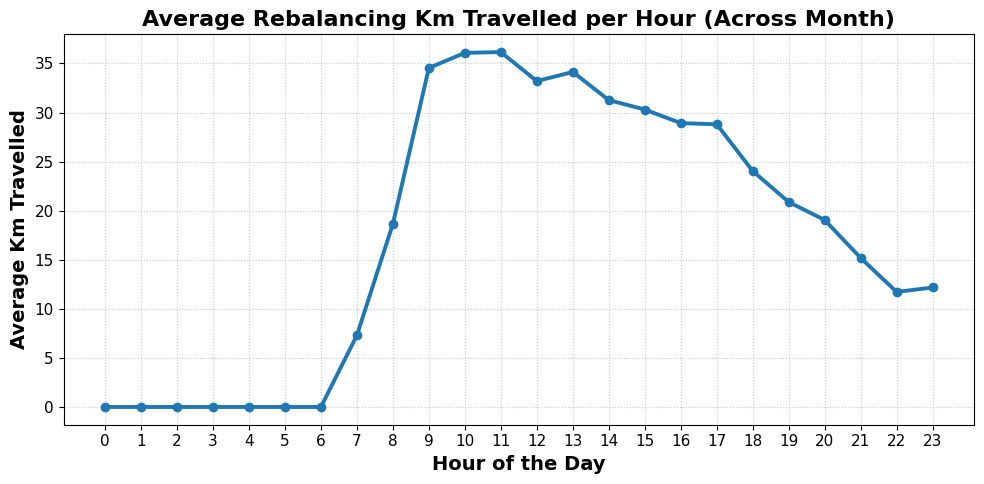

In [67]:
# Parameters
start_date = datetime.strptime('2017-11-20', '%Y-%m-%d')
end_date = datetime.strptime('2017-12-19', '%Y-%m-%d')

# Store total_distance per hour across all days
hourly_distances = {h: [] for h in range(24)}

current_date = start_date
while current_date <= end_date:
    # Read hourly rebalancing metrics
    df_hourly = pd.read_csv(f'..\\simulation_results\\rebalancing_metrics\\hourly_rebalancing_metrics_{str(current_date)[:-8]}.csv')
    
    # Convert 'hour' column to integer 0-23
    df_hourly['hour'] = pd.to_datetime(df_hourly['hour']).dt.hour
    
    for h in range(24):
        dist = df_hourly.loc[df_hourly['hour'] == h, 'total_distance'].values[0]
        hourly_distances[h].append(dist)
    
    current_date += timedelta(days=1)

# Compute average distance per hour across all days
avg_distance_per_hour = {h: sum(dists)/len(dists) for h, dists in hourly_distances.items()}

# Convert to DataFrame for plotting
avg_distance_df = pd.DataFrame({
    'hour': list(avg_distance_per_hour.keys()),
    'avg_km_travelled': list(avg_distance_per_hour.values())
})

# Plot
plt.figure(figsize=(10,5))
plt.plot(avg_distance_df['hour'], avg_distance_df['avg_km_travelled'], marker='o', color="#1f77b4")
plt.xticks(range(0,24))
plt.xlabel("Hour of the Day", fontweight="bold")
plt.ylabel("Average Km Travelled", fontweight="bold")
plt.title("Average Rebalancing Km Travelled per Hour (Across Month)", fontweight="bold")
plt.grid(True, linestyle=":", alpha=0.7)
plt.tight_layout()
plt.show()